## Image viewer

In this notebook, we show several ways to look at images\
Craig Lage - 13-Mar-21

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pf
from lsst.daf.persistence import Butler
import lsst.afw.cameraGeom.utils as camGeomUtils
import lsst.afw.display as afwDisplay

In [2]:
# Instantiate the butler
REPO_DIR = '/project/shared/auxTel'
butler = Butler(REPO_DIR)

In [3]:
# Get the raw data
dayObs = '2021-02-17'
expId=2021021700349
exp = butler.get('raw', detector=0, expId=expId)
mean = np.mean(exp.getMaskedImage().getArrays()[0])
std = np.std(exp.getMaskedImage().getArrays()[0])
print(mean, std)

15719.127 13055.668


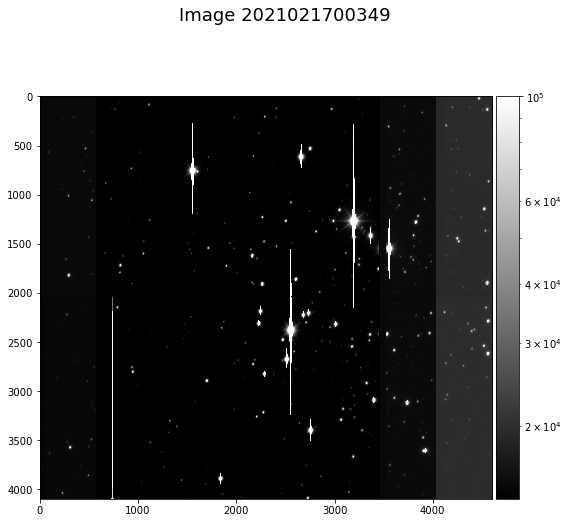

In [4]:
# Look at the data with matplotlib
# The raw data doesn't look very good, because of the large pedestal of about 15,000 ADU
from matplotlib.colors import LogNorm
# Now let's look at ithem
def colorbar(mappable):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    plt.sca(last_axes)
    return cbar

plt.figure(figsize=(8,8))
plt.suptitle(f"Image {expId}",fontsize=18)
arr = exp.image.array
img = plt.imshow(arr, norm=LogNorm(vmin=14000, vmax=100000), interpolation='Nearest', cmap='gray')
colorbar(img)
plt.tight_layout(h_pad=1)
#plt.savefig(REPO_DIR+"/plots/NGC4755_17Feb21.pdf")

In [5]:
# Get the quickLook data
# This has had some level of ISR done to it, including overscan subtraction
# and bias subtraction, so the images are better
REPO_DIR = '/project/shared/auxTel/rerun/quickLook'
butler = Butler(REPO_DIR)
dayObs = '2021-02-17'
expId=2021021700349
exp = butler.get('quickLookExp', detector=0, expId=expId)
mean = np.mean(exp.getMaskedImage().getArrays()[0])
std = np.std(exp.getMaskedImage().getArrays()[0])
print(mean, std)

Ignoring translator header fixup of LATISS AT_O_20210217_000349: 'MJD-OBS not found'


1577.5114 13418.808


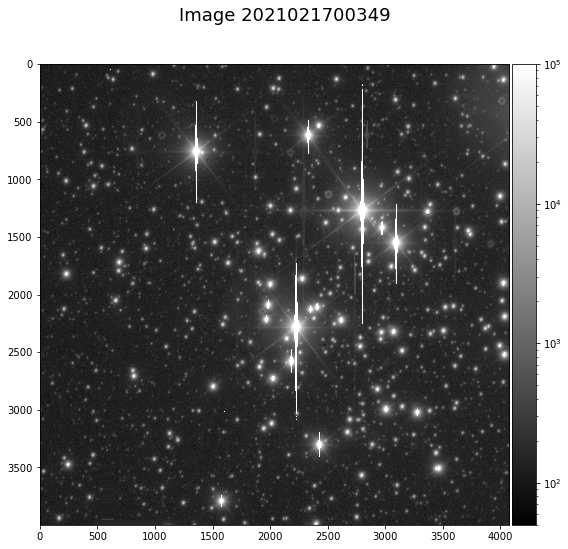

In [6]:
# Look at the data with matplotlib
# Looks much better
from matplotlib.colors import LogNorm
# Now let's look at ithem
def colorbar(mappable):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    plt.sca(last_axes)
    return cbar

plt.figure(figsize=(8,8))
plt.suptitle(f"Image {expId}",fontsize=18)
arr = exp.image.array
img = plt.imshow(arr, norm=LogNorm(vmin=50, vmax=100000), interpolation='Nearest', cmap='gray')
colorbar(img)
plt.tight_layout(h_pad=1)
#plt.savefig(REPO_DIR+"/plots/NGC4755_17Feb21.pdf")

In [7]:
# You can also display the images with Firefly, which I am just learning.
# The Firefly diplay will open in a separate browser tab
afwDisplay.setDefaultBackend('firefly')
display1 = afwDisplay.Display(frame=1)

In [8]:
# This will load the image into Firefly
# Firefly has many of the attributes of DS9.
display1.mtv(exp)

Ignoring translator header fixup of LATISS AT_O_20210217_000349: 'MJD-OBS not found'


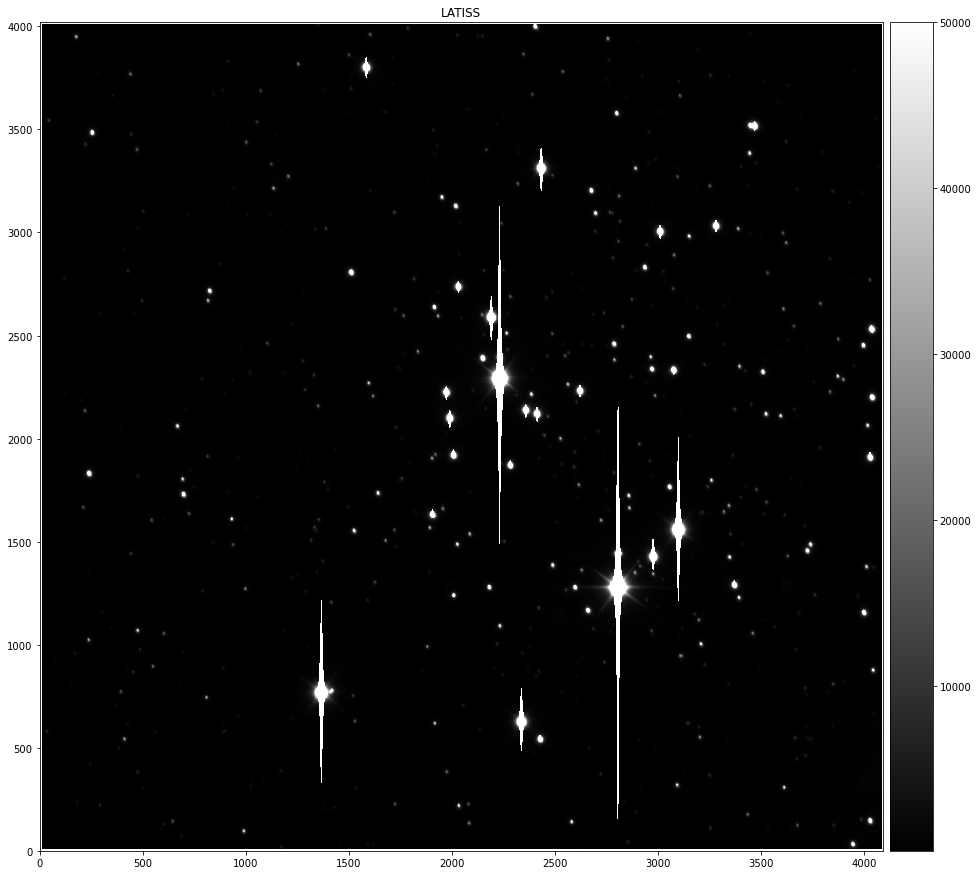

In [11]:
# You can also display the image using camera.  this will be more
# important with ComCam and LSSTCam, where we have multiple CCDs
# Haven't figured out a log stretch yet.
camera = butler.get('camera')
fig = plt.figure(figsize=(16,16))
disp = afwDisplay.Display(1, "matplotlib")
disp.scale('linear',min=50,max=50000)
dataType='quickLookExp'
mos = camGeomUtils.showCamera(camera, \
                              camGeomUtils.ButlerImage(butler, dataType, expId=expId, \
                                                        verbose=True,  \
                                                      background = np.nan),\
                              title='',\
                              binSize=1, display=disp, overlay=False)
#fig.savefig(REPO_DIR+'/plots/%s_%d_%s.png'%(testType,visit,dayObs))